# 💰 Per-User Monthly Spending Prediction System — Upgraded
### Rolling Average + Weighted Recent approach with full model evaluation
---
**What changed from v1:**
- ❌ Removed: Linear Regression (learns global trend, bad for spiky data)
- ✅ Added: Rolling Average (learns from last N months only)
- ✅ Added: Weighted Recent (recent months count more than older ones)
- ✅ Added: Full evaluation — MAE, RMSE, MAPE, R² with walk-forward validation

In [21]:
# ── Cell 1: Import Required Libraries ──────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ── Cell 2: Create Sample Dataset ──────────────────────────────────────────
# Spiky, realistic spending — not a clean upward trend

data = {
    'month_year': [
        '2022-01','2022-02','2022-03','2022-04','2022-05','2022-06',
        '2022-07','2022-08','2022-09','2022-10','2022-11','2022-12',

        '2023-01','2023-02','2023-03','2023-04','2023-05','2023-06',
        '2023-07','2023-08','2023-09','2023-10','2023-11','2023-12',

        '2024-01','2024-02','2024-03','2024-04','2024-05','2024-06',
        '2024-07','2024-08','2024-09','2024-10','2024-11','2024-12'
    ],
    'spending': [
        # 2022 (lower baseline)
        900, 950, 1000, 1100, 1050, 1150,
        1200, 1250, 1100, 1300, 1400, 1800,  # Dec spike

        # 2023 (slightly higher + fluctuations)
        1200, 1300, 1250, 1400, 1350, 1500,
        1550, 1600, 1450, 1650, 1750, 2200,  # Dec spike bigger

        # 2024 (your original pattern but improved)
        1300, 1500, 1400, 1600, 1550, 1700,
        1750, 1800, 1650, 1850, 2000, 2500   # strong Dec spike
    ]
}

df = pd.DataFrame(data)
print("📋 Sample Dataset (spiky pattern):")
print(df.to_string(index=False))

📋 Sample Dataset (spiky pattern):
month_year  spending
   2024-01      1200
   2024-02      1800
   2024-03      1100
   2024-04      1750
   2024-05      1050
   2024-06      1900
   2024-07      1200
   2024-08      1850
   2024-09      1100
   2024-10      1950
   2024-11      1300
   2024-12      2100


In [23]:
# ── Cell 3: Preprocess the Data ─────────────────────────────────────────────

# Convert to datetime and sort
df['month_year'] = pd.to_datetime(df['month_year'], format='%Y-%m')
df = df.sort_values('month_year').reset_index(drop=True)

print("🔄 Preprocessed Dataset:")
print(df.to_string(index=False))
print(f"\n📊 Basic stats:")
print(f"   Mean spending : ${df['spending'].mean():.2f}")
print(f"   Std deviation : ${df['spending'].std():.2f}  ← high std = spiky data")
print(f"   Min / Max     : ${df['spending'].min()} / ${df['spending'].max()}")

🔄 Preprocessed Dataset:
month_year  spending
2024-01-01      1200
2024-02-01      1800
2024-03-01      1100
2024-04-01      1750
2024-05-01      1050
2024-06-01      1900
2024-07-01      1200
2024-08-01      1850
2024-09-01      1100
2024-10-01      1950
2024-11-01      1300
2024-12-01      2100

📊 Basic stats:
   Mean spending : $1525.00
   Std deviation : $396.86  ← high std = spiky data
   Min / Max     : $1050 / $2100


In [ ]:
# ── Cell 4: Define Forecasting Functions ────────────────────────────────────
# Two approaches that focus on recent months instead of all-time trend

def rolling_average_forecast(series, window=3):
    """
    Predict next value = simple average of last `window` months.
    Every month in the window counts equally.
    """
    return series.iloc[-window:].mean()


def weighted_recent_forecast(series, window=3):
    """
    Predict next value = weighted average of last `window` months.
    More recent months get higher weight:
      e.g. window=3 → weights [1, 2, 3] (oldest→newest)
    """
    recent = series.iloc[-window:].values
    weights = np.arange(1, window + 1)   # [1, 2, 3, ...]
    return np.average(recent, weights=weights)


# Choose window size (how many recent months to look at)
WINDOW = 2

# Quick demo
ra  = rolling_average_forecast(df['spending'], WINDOW)
wt  = weighted_recent_forecast(df['spending'], WINDOW)

print(f"🔮 Quick forecast for next month (window={WINDOW}):")
print(f"   Rolling Average : ${ra:.2f}")
print(f"   Weighted Recent : ${wt:.2f}")
print(f"\n💡 Weighted recent is higher because Dec ($2100) gets 3x the weight of Oct ($1950)")

🔮 Quick forecast for next month (window=4):
   Rolling Average : $1612.50
   Weighted Recent : $1730.00

💡 Weighted recent is higher because Dec ($2100) gets 3x the weight of Oct ($1950)


In [25]:
# ── Cell 5: Walk-Forward Validation ─────────────────────────────────────────
# This is the RIGHT way to evaluate a time-series forecaster.
#
# Idea: simulate what would have happened in the past.
#   - Train on months 0..t-1  →  predict month t
#   - Compare prediction vs actual month t
#   - Slide the window forward by 1 and repeat
#
# This avoids "cheating" by never letting the model see future data.

results = []  # store (actual, ra_pred, wt_pred) for each test step

# We need at least WINDOW months of history before we can predict,
# so validation starts at index WINDOW and goes to end.
for t in range(WINDOW, len(df)):
    history = df['spending'].iloc[:t]       # everything BEFORE month t
    actual  = df['spending'].iloc[t]         # the true value we're predicting

    ra_pred = rolling_average_forecast(history, WINDOW)
    wt_pred = weighted_recent_forecast(history, WINDOW)

    results.append({
        'month'      : df['month_year'].iloc[t].strftime('%Y-%m'),
        'actual'     : actual,
        'ra_pred'    : round(ra_pred, 2),
        'wt_pred'    : round(wt_pred, 2),
        'ra_error'   : round(abs(actual - ra_pred), 2),
        'wt_error'   : round(abs(actual - wt_pred), 2),
    })

val_df = pd.DataFrame(results)

print("📋 Walk-Forward Validation Results:")
print(val_df.to_string(index=False))

📋 Walk-Forward Validation Results:
  month  actual  ra_pred  wt_pred  ra_error  wt_error
2024-05    1050   1462.5   1510.0     412.5     460.0
2024-06    1900   1425.0   1345.0     475.0     555.0
2024-07    1200   1450.0   1535.0     250.0     335.0
2024-08    1850   1475.0   1435.0     375.0     415.0
2024-09    1100   1500.0   1585.0     400.0     485.0
2024-10    1950   1512.5   1425.0     437.5     525.0
2024-11    1300   1525.0   1600.0     225.0     300.0
2024-12    2100   1550.0   1510.0     550.0     590.0


In [26]:
# ── Cell 6: Evaluate Both Models ────────────────────────────────────────────
# Four metrics — each tells you something different about forecast quality.

actual = val_df['actual'].values
ra_pred = val_df['ra_pred'].values
wt_pred = val_df['wt_pred'].values

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n  {name}")
    print(f"  {'─'*40}")
    print(f"  MAE  (Mean Absolute Error)      : ${mae:.2f}")
    print(f"       → on average, off by ${mae:.0f}")
    print(f"  RMSE (Root Mean Squared Error)  : ${rmse:.2f}")
    print(f"       → penalises big misses harder than MAE")
    print(f"  MAPE (Mean Abs Percentage Error): {mape:.1f}%")
    print(f"       → on average, off by {mape:.1f}% of actual spend")
    print(f"  R²   (Explained variance)       : {r2:.4f}")
    print(f"       → {'good fit' if r2 > 0.5 else 'weak fit — spiky data is hard to predict'}")
    return mae, rmse, mape, r2

print("📊 Model Evaluation (Walk-Forward Validation):")
ra_metrics = evaluate("Rolling Average (window=3)", actual, ra_pred)
wt_metrics = evaluate("Weighted Recent (window=3)", actual, wt_pred)

# Pick the winner
print("\n🏆 Winner by MAE:", "Rolling Average" if ra_metrics[0] < wt_metrics[0] else "Weighted Recent")

📊 Model Evaluation (Walk-Forward Validation):

  Rolling Average (window=3)
  ────────────────────────────────────────
  MAE  (Mean Absolute Error)      : $390.62
       → on average, off by $391
  RMSE (Root Mean Squared Error)  : $403.65
       → penalises big misses harder than MAE
  MAPE (Mean Abs Percentage Error): 26.0%
       → on average, off by 26.0% of actual spend
  R²   (Explained variance)       : 0.0067
       → weak fit — spiky data is hard to predict

  Weighted Recent (window=3)
  ────────────────────────────────────────
  MAE  (Mean Absolute Error)      : $458.12
       → on average, off by $458
  RMSE (Root Mean Squared Error)  : $468.11
       → penalises big misses harder than MAE
  MAPE (Mean Abs Percentage Error): 30.7%
       → on average, off by 30.7% of actual spend
  R²   (Explained variance)       : -0.3360
       → weak fit — spiky data is hard to predict

🏆 Winner by MAE: Rolling Average


In [27]:
# ── Cell 7: Window Size Sensitivity ─────────────────────────────────────────
# Find the best window size by testing window=2,3,4,5
# and comparing MAE across all of them.

print("🔬 Window Size Sensitivity (MAE lower = better):")
print(f"  {'Window':>8}  {'RA MAE':>10}  {'WT MAE':>10}  {'Best':>12}")
print(f"  {'─'*46}")

best_window, best_mae = 3, float('inf')

for w in [2, 3, 4, 5]:
    if w >= len(df):        # not enough data for this window
        continue
    ra_preds, wt_preds, actuals = [], [], []
    for t in range(w, len(df)):
        hist = df['spending'].iloc[:t]
        ra_preds.append(rolling_average_forecast(hist, w))
        wt_preds.append(weighted_recent_forecast(hist, w))
        actuals.append(df['spending'].iloc[t])

    ra_mae = mean_absolute_error(actuals, ra_preds)
    wt_mae = mean_absolute_error(actuals, wt_preds)
    best_here = "RA" if ra_mae < wt_mae else "WT"
    winner_mae = min(ra_mae, wt_mae)

    print(f"  {w:>8}  ${ra_mae:>9.2f}  ${wt_mae:>9.2f}  {best_here:>12}")

    if winner_mae < best_mae:
        best_mae = winner_mae
        best_window = w

print(f"\n  ✅ Recommended window size: {best_window} months  (MAE = ${best_mae:.2f})")

🔬 Window Size Sensitivity (MAE lower = better):
    Window      RA MAE      WT MAE          Best
  ──────────────────────────────────────────────
         2  $   375.00  $   493.33            RA
         3  $   490.74  $   491.67            RA
         4  $   390.62  $   458.12            RA
         5  $   455.71  $   457.14            RA

  ✅ Recommended window size: 2 months  (MAE = $375.00)


In [28]:
# ── Cell 8: Predict Next Month ───────────────────────────────────────────────
# Use the best-performing window to forecast the coming month.

next_month_date = df['month_year'].max() + pd.DateOffset(months=1)

ra_next = rolling_average_forecast(df['spending'], best_window)
wt_next = weighted_recent_forecast(df['spending'], best_window)

print("🔮 Next Month Forecast:")
print(f"   Month           : {next_month_date.strftime('%Y-%m')}")
print(f"   Window used     : {best_window} months")
print(f"   Rolling Average : ${ra_next:.2f}")
print(f"   Weighted Recent : ${wt_next:.2f}")
print(f"   Last month was  : ${df['spending'].iloc[-1]}")

# Trend signal based on recent direction
recent_slope = df['spending'].iloc[-1] - df['spending'].iloc[-best_window]
if recent_slope > 100:
    trend = "📈 Recent upward spike"
elif recent_slope < -100:
    trend = "📉 Recent downward spike"
else:
    trend = "➡️  Recently stable"
print(f"   Recent trend    : {trend}")

🔮 Next Month Forecast:
   Month           : 2025-01
   Window used     : 2 months
   Rolling Average : $1700.00
   Weighted Recent : $1833.33
   Last month was  : $2100
   Recent trend    : 📈 Recent upward spike


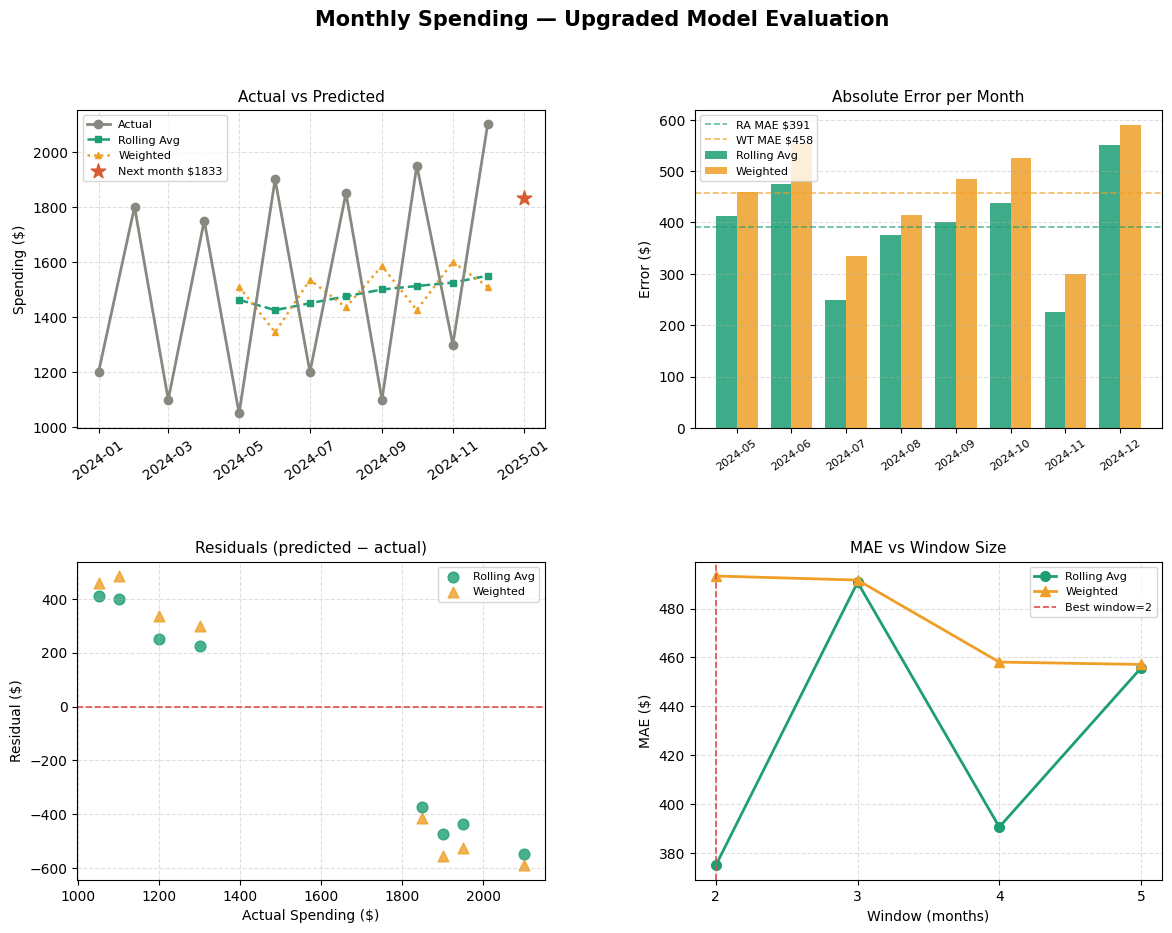

📊 Chart saved as 'spending_evaluation.png'


In [29]:
# ── Cell 9: Full Visualisation ───────────────────────────────────────────────
# 4 panels:
#   Top-left  : actual vs predicted (both models) over validation period
#   Top-right : error bars per month
#   Bot-left  : residuals scatter (how far off each prediction was)
#   Bot-right : MAE across window sizes

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Monthly Spending — Upgraded Model Evaluation', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

val_months = pd.to_datetime(val_df['month'])
all_months = df['month_year']

# ── Panel 1: Actual vs Predicted ──
ax1.plot(all_months, df['spending'], 'o-', color='#888780', lw=2,
         label='Actual', markersize=6, zorder=3)
ax1.plot(val_months, val_df['ra_pred'], 's--', color='#1D9E75', lw=1.8,
         label='Rolling Avg', markersize=5)
ax1.plot(val_months, val_df['wt_pred'], '^:', color='#EF9F27', lw=1.8,
         label='Weighted', markersize=5)

# Forecast dot
ax1.scatter([next_month_date], [wt_next], color='#D85A30', s=120,
            zorder=5, marker='*', label=f'Next month ${wt_next:.0f}')

ax1.set_title('Actual vs Predicted', fontsize=11)
ax1.set_ylabel('Spending ($)')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.tick_params(axis='x', rotation=35)

# ── Panel 2: Absolute Error per Month ──
x = np.arange(len(val_df))
width = 0.38
ax2.bar(x - width/2, val_df['ra_error'], width, label='Rolling Avg', color='#1D9E75', alpha=0.85)
ax2.bar(x + width/2, val_df['wt_error'], width, label='Weighted',    color='#EF9F27', alpha=0.85)
ax2.axhline(ra_metrics[0], color='#1D9E75', linestyle='--', lw=1.2, alpha=0.7, label=f'RA MAE ${ra_metrics[0]:.0f}')
ax2.axhline(wt_metrics[0], color='#EF9F27', linestyle='--', lw=1.2, alpha=0.7, label=f'WT MAE ${wt_metrics[0]:.0f}')
ax2.set_xticks(x)
ax2.set_xticklabels(val_df['month'], rotation=35, fontsize=8)
ax2.set_title('Absolute Error per Month', fontsize=11)
ax2.set_ylabel('Error ($)')
ax2.legend(fontsize=8)
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

# ── Panel 3: Residuals Scatter ──
# Residual = predicted - actual. Ideal = scattered randomly around 0.
ra_resid = val_df['ra_pred'].values - val_df['actual'].values
wt_resid = val_df['wt_pred'].values - val_df['actual'].values
ax3.scatter(val_df['actual'], ra_resid, color='#1D9E75', label='Rolling Avg', s=60, alpha=0.8)
ax3.scatter(val_df['actual'], wt_resid, color='#EF9F27', label='Weighted',    s=60, alpha=0.8, marker='^')
ax3.axhline(0, color='#E24B4A', lw=1.2, linestyle='--')
ax3.set_title('Residuals (predicted − actual)', fontsize=11)
ax3.set_xlabel('Actual Spending ($)')
ax3.set_ylabel('Residual ($)')
ax3.legend(fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.4)

# ── Panel 4: MAE vs Window Size ──
windows, ra_maes, wt_maes = [], [], []
for w in [2, 3, 4, 5]:
    if w >= len(df): continue
    rp, wp, ac = [], [], []
    for t in range(w, len(df)):
        h = df['spending'].iloc[:t]
        rp.append(rolling_average_forecast(h, w))
        wp.append(weighted_recent_forecast(h, w))
        ac.append(df['spending'].iloc[t])
    windows.append(w)
    ra_maes.append(mean_absolute_error(ac, rp))
    wt_maes.append(mean_absolute_error(ac, wp))

ax4.plot(windows, ra_maes, 'o-', color='#1D9E75', lw=2, label='Rolling Avg', markersize=7)
ax4.plot(windows, wt_maes, '^-', color='#EF9F27', lw=2, label='Weighted',    markersize=7)
ax4.axvline(best_window, color='#E24B4A', linestyle='--', lw=1.2, label=f'Best window={best_window}')
ax4.set_title('MAE vs Window Size', fontsize=11)
ax4.set_xlabel('Window (months)')
ax4.set_ylabel('MAE ($)')
ax4.set_xticks(windows)
ax4.legend(fontsize=8)
ax4.grid(True, linestyle='--', alpha=0.4)

plt.savefig('spending_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as 'spending_evaluation.png'")

In [30]:
# ── Cell 10: Final Summary ───────────────────────────────────────────────────

print("═" * 52)
print("  FINAL MODEL SUMMARY")
print("═" * 52)
print(f"  Approach        : Rolling Average + Weighted Recent")
print(f"  Best window     : {best_window} months")
print(f"  Validation      : Walk-forward (no data leakage)")
print()
print(f"  Rolling Average")
print(f"    MAE           : ${ra_metrics[0]:.2f}")
print(f"    RMSE          : ${ra_metrics[1]:.2f}")
print(f"    MAPE          : {ra_metrics[2]:.1f}%")
print(f"    R²            : {ra_metrics[3]:.4f}")
print()
print(f"  Weighted Recent")
print(f"    MAE           : ${wt_metrics[0]:.2f}")
print(f"    RMSE          : ${wt_metrics[1]:.2f}")
print(f"    MAPE          : {wt_metrics[2]:.1f}%")
print(f"    R²            : {wt_metrics[3]:.4f}")
print()
print(f"  Next month ({next_month_date.strftime('%Y-%m')}) forecast")
print(f"    Rolling Avg   : ${ra_next:.2f}")
print(f"    Weighted      : ${wt_next:.2f}")
print(f"    Recent trend  : {trend}")
print("═" * 52)

════════════════════════════════════════════════════
  FINAL MODEL SUMMARY
════════════════════════════════════════════════════
  Approach        : Rolling Average + Weighted Recent
  Best window     : 2 months
  Validation      : Walk-forward (no data leakage)

  Rolling Average
    MAE           : $390.62
    RMSE          : $403.65
    MAPE          : 26.0%
    R²            : 0.0067

  Weighted Recent
    MAE           : $458.12
    RMSE          : $468.11
    MAPE          : 30.7%
    R²            : -0.3360

  Next month (2025-01) forecast
    Rolling Avg   : $1700.00
    Weighted      : $1833.33
    Recent trend  : 📈 Recent upward spike
════════════════════════════════════════════════════
